First, checking the shape of our images. These will be kept in the same shape to preserve information, and then later will be coverted to 3 channels and resized the fit the requirements of the medSAM.

In [ ]:
import nibabel as nib
raw_volume = nib.load("/content/drive/MyDrive/BTCV/images/img0001.nii")
print("Original Volume Shape:", raw_volume.shape)

FileNotFoundError: No such file or no access: '/content/drive/MyDrive/BTCV/images/img0001.nii'

In [ ]:
import os
import json
import numpy as np
import nibabel as nib
from skimage import transform
from tqdm import tqdm

base_path = '/content/drive/MyDrive/BTCV'
img_input_dir = os.path.join(base_path, 'images')
label_input_dir = os.path.join(base_path, 'labels')

out_dir = '/content/drive/MyDrive/processed_medsam' #mounted the output to drive to reduce no. of re runs.
out_img_dir = os.path.join(out_dir, 'images')
out_mask_dir = os.path.join(out_dir, 'masks')
os.makedirs(out_img_dir, exist_ok=True)
os.makedirs(out_mask_dir, exist_ok=True)

# Dictionary mapping the integer values found inside the BTCV labels to their actual string names
organ_mapping = {
    1: "spleen",
    6: "liver",
    11: "pancreas"
}
train_scans = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 21, 22, 23, 24]  # 14 patients for training
val_scans = [25, 26, 27]                                      # 3 patients for validation
test_scans = [28, 29, 30]                                     # 3 patients for testing

train_metadata = []
val_metadata = []
test_metadata = []

all_scan_ids = train_scans + val_scans + test_scans


# progress bar will be visible using tqdm
for idx in tqdm(all_scan_ids):

    img_path = os.path.join(img_input_dir, f'img{idx:04d}.nii')
    label_path = os.path.join(label_input_dir, f'label{idx:04d}.nii')
    if not os.path.exists(img_path):
        continue

    img_vol = nib.load(img_path).get_fdata()
    label_vol = nib.load(label_path).get_fdata()
    if idx in train_scans:
        current_split_metadata = train_metadata
    elif idx in val_scans:
        current_split_metadata = val_metadata
    else:
        current_split_metadata = test_metadata
# checking each layer / slice of the scan
    for slice_idx in range(img_vol.shape[2]):

        # the output / actual label
        mask_slice = label_vol[:, :, slice_idx]
        unique_organs = np.unique(mask_slice)


        found_organs = [oid for oid in organ_mapping.keys() if oid in unique_organs]
        if found_organs:
            img_slice = img_vol[:, :, slice_idx]

            # Adjust CT scans to soft tissue window level (40) and width (400) ; then normalise
            img_slice = np.clip(img_slice, -160, 240)
            img_slice = (img_slice - (-160)) / (240 - (-160))

            img_single_channel = img_slice.astype(np.float32)
            for organ_id in found_organs:
                organ_name = organ_mapping[organ_id]
                mask_organ = (mask_slice == organ_id).astype(np.uint8)
                file_id = f'{organ_name}_scan{idx:02d}_slice{slice_idx:03d}'
                img_filename = f'{file_id}_img.npy'
                mask_filename = f'{file_id}_mask.npy'
                np.save(os.path.join(out_img_dir, img_filename), img_single_channel)
                np.save(os.path.join(out_mask_dir, mask_filename), mask_organ)
                current_split_metadata.append({
                    "image_path": os.path.join('images', img_filename),
                    "mask_path": os.path.join('masks', mask_filename),
                    "prompt": organ_name
                })

with open(os.path.join(out_dir, 'train_manifest.json'), 'w') as f:
    json.dump(train_metadata, f, indent=4)

with open(os.path.join(out_dir, 'val_manifest.json'), 'w') as f:
    json.dump(val_metadata, f, indent=4)

with open(os.path.join(out_dir, 'test_manifest.json'), 'w') as f:
    json.dump(test_metadata, f, indent=4)

print(f"Train samples: {len(train_metadata)} | Val samples: {len(val_metadata)} | Test samples: {len(test_metadata)}")

100%|██████████| 20/20 [28:07<00:00, 84.38s/it]


Train samples: 1666 | Val samples: 197 | Test samples: 328


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!pip install git+https://github.com/bowang-lab/MedSAM.git
!pip install transformers ipympl
!gdown 10lk-H-7N4U11n9fJv2bZuNH7kFWtIZVB
!gdown 12YH-N6PAKayulhS99MBURVNpuQtVj98S
!gdown 1UAmWL88roYR7wKlnApw5Bcuzf2iQgk6_

  Cloning https://github.com/bowang-lab/MedSAM.git to /tmp/pip-req-build-t94qzql1
  Running command git clone --filter=blob:none --quiet https://github.com/bowang-lab/MedSAM.git /tmp/pip-req-build-t94qzql1
  Resolved https://github.com/bowang-lab/MedSAM.git to commit d71e8a1a99ad751840a22a7fa3ecfb4166fb1488
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.0/519.0 kB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 92.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 113.6 MB/s eta 0:00:00
  Created wheel for medsam: filename=medsam-0.0.1-py3-none-any.whl size=37340 sha256=c8dd5fc853b1a67cce0c6d4e453af2cc018b346cb3dc4110ae15ef2f9ec2fdbf
  Stored in directory: /tmp

In [ ]:
import os
import cv2
import torch
import warnings
import numpy as np
from torch import nn
from copy import deepcopy
from matplotlib import pyplot as plt
from torch.nn import functional as F
from typing import Any, Optional, Tuple, Type
from transformers import CLIPTextModel
from segment_anything import sam_model_registry
from segment_anything.modeling import PromptEncoder
join = os.path.join
%matplotlib inline
warnings.filterwarnings('ignore')

The below cell is taken directly from the tutorial without any modifications.

In [ ]:
class TextPromptEncoder(PromptEncoder):
    def __init__(
        self,
        embed_dim: int,
        image_embedding_size: Tuple[int, int],
        input_image_size: Tuple[int, int],
        mask_in_chans: int = 1,
        activation = nn.GELU,
        ) -> None:
        super().__init__(embed_dim, image_embedding_size, input_image_size, mask_in_chans, activation)
        text_encoder = CLIPTextModel.from_pretrained("openai/clip-vit-base-patch16")
        text_encoder.requires_grad_(False)
        self.text_encoder = text_encoder
        self.text_encoder_head = nn.Linear(512, embed_dim)

    def forward(
        self,
        points: Optional[Tuple[torch.Tensor, torch.Tensor]],
        boxes: Optional[torch.Tensor],
        masks: Optional[torch.Tensor],
        tokens: Optional[torch.Tensor],
    ):
        """
        Embeds different types of prompts, returning both sparse and dense
        embeddings.

        Arguments:
          points (tuple(torch.Tensor, torch.Tensor) or none): point coordinates
            and labels to embed.
          boxes (torch.Tensor or none): boxes to embed
          masks (torch.Tensor or none): masks to embed

        Returns:
          torch.Tensor: sparse embeddings for the points and boxes, with shape
            BxNx(embed_dim), where N is determined by the number of input points
            and boxes.
          torch.Tensor: dense embeddings for the masks, in the shape
            Bx(embed_dim)x(embed_H)x(embed_W)
        """
        bs = self._get_batch_size(points, boxes, masks, tokens)
        sparse_embeddings = torch.empty(
            (bs, 0, self.embed_dim), device=self._get_device()
        )
        if points is not None:
            coords, labels = points
            point_embeddings = self._embed_points(coords, labels, pad=(boxes is None))
            sparse_embeddings = torch.cat([sparse_embeddings, point_embeddings], dim=1)
        if boxes is not None:
            box_embeddings = self._embed_boxes(boxes)
            sparse_embeddings = torch.cat([sparse_embeddings, box_embeddings], dim=1)
        if tokens is not None:
            encoder_hidden_states = self.text_encoder(tokens)[0]
            text_embeddings = self.text_encoder_head(encoder_hidden_states)
            sparse_embeddings = torch.cat([sparse_embeddings, text_embeddings], dim=1)

        if masks is not None:
            dense_embeddings = self._embed_masks(masks)
        else:
            dense_embeddings = self.no_mask_embed.weight.reshape(1, -1, 1, 1).expand(
                bs, -1, self.image_embedding_size[0], self.image_embedding_size[1]
            )

        return sparse_embeddings, dense_embeddings

    def _get_batch_size(self, points, boxes, masks, tokens):
        """
        Returns the batch size of the inputs.
        """
        if points is not None:
            return points[0].shape[0]
        elif boxes is not None:
            return boxes.shape[0]
        elif masks is not None:
            return masks.shape[0]
        elif tokens is not None:
            return tokens.shape[0]
        else:
            return 1

again, this part is taken directly as well. Defines the medSAM model structure.

In [ ]:
class MedSAMText(nn.Module):
    def __init__(self,
                image_encoder,
                mask_decoder,
                prompt_encoder,
                device,
                ):
        super().__init__()
        self.image_encoder = image_encoder
        self.mask_decoder = mask_decoder
        self.prompt_encoder = prompt_encoder
        self.device = device

    def forward(self, image, tokens):
        image_embedding = self.image_encoder(image) # (B, 256, 64, 64)
        sparse_embeddings, dense_embeddings = self.prompt_encoder(
            points=None,
            boxes=None,
            masks=None,
            tokens=tokens
        )
        low_res_logits, _ = self.mask_decoder(
            image_embeddings=image_embedding, # (B, 256, 64, 64)
            image_pe=self.prompt_encoder.get_dense_pe(), # (1, 256, 64, 64)
            sparse_prompt_embeddings=sparse_embeddings, # (B, 2, 256)
            dense_prompt_embeddings=dense_embeddings, # (B, 256, 64, 64)
            multimask_output=False,
          ) # (B, 1, 256, 256)

        return low_res_logits

again, the part with the text demo form the tutorial is ommited, but the rest is kept as is.

In [ ]:
medsam_ckpt_path = "medsam_vit_b.pth"
device = "cuda:0"
medsam_model = sam_model_registry['vit_b'](checkpoint=medsam_ckpt_path)
text_prompt_encoder = TextPromptEncoder(
    embed_dim = 256,
    image_embedding_size = (64, 64),
    input_image_size = (1024, 1024),
    mask_in_chans = 1
)
medsam_text_demo = MedSAMText(
    image_encoder=deepcopy(medsam_model.image_encoder),
    mask_decoder=deepcopy(medsam_model.mask_decoder),
    prompt_encoder=text_prompt_encoder,
    device = device
)

config.json:   0%|          | 0.00/4.10k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/599M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

[transformers] CLIPTextModel LOAD REPORT from: openai/clip-vit-base-patch16
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
vision_model.embeddings.patch_embedding.weight                 | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.l

Just debugging to check the actual number of trainable parameters. These are around 4.2 million, in the correct range, and only 2 types of layers- namely the mask decoder and the prompt encoder are having learable weights.

In [ ]:
for param in medsam_text_demo.image_encoder.parameters():
    param.requires_grad = False

for param in medsam_text_demo.prompt_encoder.text_encoder.parameters():
    param.requires_grad = False

# 3. Confirmation "Roll Call"
print("--- Trainable Parameters Check ---")
trainable_count = 0
for name, param in medsam_text_demo.named_parameters():
    if param.requires_grad:
        print(f"Yes: {name}")
        trainable_count += param.numel()

print(f"\nTotal trainable parameters: {trainable_count:,}")

--- Trainable Parameters Check ---
Yes: mask_decoder.transformer.layers.0.self_attn.q_proj.weight
Yes: mask_decoder.transformer.layers.0.self_attn.q_proj.bias
Yes: mask_decoder.transformer.layers.0.self_attn.k_proj.weight
Yes: mask_decoder.transformer.layers.0.self_attn.k_proj.bias
Yes: mask_decoder.transformer.layers.0.self_attn.v_proj.weight
Yes: mask_decoder.transformer.layers.0.self_attn.v_proj.bias
Yes: mask_decoder.transformer.layers.0.self_attn.out_proj.weight
Yes: mask_decoder.transformer.layers.0.self_attn.out_proj.bias
Yes: mask_decoder.transformer.layers.0.norm1.weight
Yes: mask_decoder.transformer.layers.0.norm1.bias
Yes: mask_decoder.transformer.layers.0.cross_attn_token_to_image.q_proj.weight
Yes: mask_decoder.transformer.layers.0.cross_attn_token_to_image.q_proj.bias
Yes: mask_decoder.transformer.layers.0.cross_attn_token_to_image.k_proj.weight
Yes: mask_decoder.transformer.layers.0.cross_attn_token_to_image.k_proj.bias
Yes: mask_decoder.transformer.layers.0.cross_attn_t

In [ ]:
# decreased learning rate and used a combination of BCE and DICE loss.
# now will ensure i save the best weights , add validation loss and then at the end, test loss.

import os
import json
import random
import torch
import torch.nn.functional as F
from transformers import CLIPTokenizer

out_dir ='/content/drive/MyDrive/processed_medsam'
# 1. Initialize the lightweight text lookup tool
tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-base-patch16")

def compute_hybrid_loss(pred_logits, targets, smooth=1e-5):
    # used this combination as using only dice loss was leading to a constant loss of 1 for all slices.
    bce_loss = F.binary_cross_entropy_with_logits(pred_logits, targets)
    probs = torch.sigmoid(pred_logits)
    intersection = (probs * targets).sum()
    union = probs.sum() + targets.sum()
    dice_loss = 1.0 - (2.0 * intersection + smooth) / (union + smooth)
    # Combining them 50/50 for stability
    return bce_loss + dice_loss

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
medsam_text_demo = medsam_text_demo.to(device)


trainable_parameters = [p for p in medsam_text_demo.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(trainable_parameters, lr=1e-4)

with open(os.path.join(out_dir, 'train_manifest.json'), 'r') as f:
    train_samples = json.load(f)
with open(os.path.join(out_dir, 'val_manifest.json'), 'r') as f:
    val_samples = json.load(f)


prompt_lookup = {}
for organ in ["liver", "spleen", "pancreas"]:
    text_inputs = tokenizer(organ, padding="max_length", max_length=77, truncation=True, return_tensors="pt")
    prompt_lookup[organ] = text_inputs['input_ids'].to(device) # Shape: (1, 77)

random.seed(42)

epochs = 4
train_losses = []
val_losses= []

best_val_loss = float('inf')
checkpoint_path = os.path.join(out_dir, "best_medsam_weights.pth")

for epoch in range(epochs):
    medsam_text_demo.train()
    running_loss = 0.0

    # Shuffles uniquely per epoch while remaining reproducible across full notebook runs
    random.shuffle(train_samples)

    for idx, sample in enumerate(train_samples):

        img_path = os.path.join(out_dir, sample['image_path'])
        mask_path = os.path.join(out_dir, sample['mask_path'])
        prompt_text = sample['prompt']

        img_np = np.load(img_path)   # Shape: (512, 512)
        mask_np = np.load(mask_path) # Shape: (512, 512)



        image_tensor = torch.from_numpy(img_np).unsqueeze(0).unsqueeze(0).float().to(device)
        mask_tensor = torch.from_numpy(mask_np).unsqueeze(0).unsqueeze(0).float().to(device)

        # Shape changes: (1, 1, 512, 512) -> (1, 3, 512, 512) to satisfy MedSAM's RGB requirement
        image_tensor = image_tensor.repeat(1, 3, 1, 1)
        image_tensor = F.interpolate(image_tensor, size=(1024, 1024), mode='bilinear', align_corners=False)

        tokens = prompt_lookup[prompt_text]

        optimizer.zero_grad()
        pred_logits = medsam_text_demo(image_tensor, tokens)
        if pred_logits.shape[-2:] != mask_tensor.shape[-2:]:
          pred_logits = F.interpolate(pred_logits, size=mask_tensor.shape[-2:], mode='bilinear', align_corners=False)

        loss = compute_hybrid_loss(pred_logits, mask_tensor)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        # Real-time console logs
        if idx % 50 == 0:
            print(f"Epoch {epoch+1}/{epochs} | Slice {idx}/{len(train_samples)} | Loss: {loss.item():.4f}")

    avg_loss = running_loss / len(train_samples)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1} Complete | Average Training Loss: {avg_loss:.4f} ---\n")

    # now validation steps, forward pass the same as training but no backward pass
    medsam_text_demo.eval()
    running_loss = 0.0
    # Dictionary to track evaluation metrics per organ type
    val_metrics = {organ: {"dice": [], "iou": []} for organ in ["liver", "spleen", "pancreas"]}
    with torch.no_grad():
      for sample in val_samples:

          img_path = os.path.join(out_dir, sample['image_path'])
          mask_path = os.path.join(out_dir, sample['mask_path'])
          prompt_text = sample['prompt']
          img_np = np.load(img_path)
          mask_np = np.load(mask_path)

          image_tensor = torch.from_numpy(img_np).unsqueeze(0).unsqueeze(0).float().to(device)
          mask_tensor = torch.from_numpy(mask_np).unsqueeze(0).unsqueeze(0).float().to(device)

          image_tensor = image_tensor.repeat(1, 3, 1, 1)
          image_tensor = F.interpolate(image_tensor, size=(1024, 1024), mode='bilinear', align_corners=False)
          tokens = prompt_lookup[prompt_text]

          pred_logits = medsam_text_demo(image_tensor, tokens)
          if pred_logits.shape[-2:] != mask_tensor.shape[-2:]:
            pred_logits = F.interpolate(pred_logits, size=mask_tensor.shape[-2:], mode='bilinear', align_corners=False)

          loss = compute_hybrid_loss(pred_logits, mask_tensor)
          running_loss += loss.item()
          #  Class-Wise Validation Metrics to be calculated
          probs = torch.sigmoid(pred_logits)
          preds = (probs > 0.5).float() # Binary threshold

          intersection = (preds * mask_tensor).sum()
          total_pixels = preds.sum() + mask_tensor.sum()

          # Compute metrics for this slice
          slice_dice = ((2.0 * intersection + 1e-5) / (total_pixels + 1e-5)).item()
          slice_iou = ((intersection + 1e-5) / (total_pixels - intersection + 1e-5)).item()

          # Append to the corresponding organ bucket
          val_metrics[prompt_text]["dice"].append(slice_dice)
          val_metrics[prompt_text]["iou"].append(slice_iou)


    avg_loss = running_loss / len(val_samples)
    val_losses.append(avg_loss)
    for organ in val_metrics:
        mean_dice = np.mean(val_metrics[organ]["dice"]) if val_metrics[organ]["dice"] else 0.0
        mean_iou = np.mean(val_metrics[organ]["iou"]) if val_metrics[organ]["iou"] else 0.0
        print(f"{organ.upper():<10} -> Mean Dice: {mean_dice:.4f} | Mean IoU: {mean_iou:.4f}")

    print(f"Epoch {epoch+1} Complete | Average Training Loss: {avg_loss:.4f} ---\n")
    if avg_loss < best_val_loss:
        best_val_loss = avg_loss

        # Save only the weights (state_dict) of the trainable layers
        torch.save(medsam_text_demo.state_dict(), checkpoint_path)
        print(f"New best validation loss achieved - Weights saved {checkpoint_path}\n")
    else:
        print("Validation loss did not improve.\n")



Epoch 1/4 | Slice 0/1666 | Loss: 1.0206
Epoch 1/4 | Slice 50/1666 | Loss: 0.9744
Epoch 1/4 | Slice 100/1666 | Loss: 0.8584
Epoch 1/4 | Slice 150/1666 | Loss: 0.1943
Epoch 1/4 | Slice 200/1666 | Loss: 0.2742
Epoch 1/4 | Slice 250/1666 | Loss: 0.7787
Epoch 1/4 | Slice 300/1666 | Loss: 1.0244
Epoch 1/4 | Slice 350/1666 | Loss: 0.1492
Epoch 1/4 | Slice 400/1666 | Loss: 0.2519
Epoch 1/4 | Slice 450/1666 | Loss: 0.1229
Epoch 1/4 | Slice 500/1666 | Loss: 0.1459
Epoch 1/4 | Slice 550/1666 | Loss: 0.1340
Epoch 1/4 | Slice 600/1666 | Loss: 0.5488
Epoch 1/4 | Slice 650/1666 | Loss: 0.7168
Epoch 1/4 | Slice 700/1666 | Loss: 0.2732
Epoch 1/4 | Slice 750/1666 | Loss: 0.1412
Epoch 1/4 | Slice 800/1666 | Loss: 0.2420
Epoch 1/4 | Slice 850/1666 | Loss: 1.1019
Epoch 1/4 | Slice 900/1666 | Loss: 0.7157
Epoch 1/4 | Slice 950/1666 | Loss: 0.7992
Epoch 1/4 | Slice 1000/1666 | Loss: 0.8891
Epoch 1/4 | Slice 1050/1666 | Loss: 1.0072
Epoch 1/4 | Slice 1100/1666 | Loss: 0.8314
Epoch 1/4 | Slice 1150/1666 | Loss

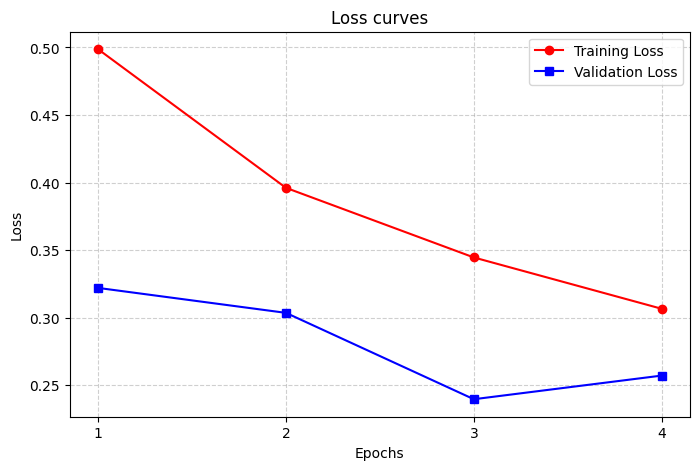

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), train_losses, label="Training Loss", marker='o', color='red')
plt.plot(range(1, epochs + 1), val_losses, label="Validation Loss", marker='s', color='blue')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss curves")
plt.xticks(range(1, epochs + 1))
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()



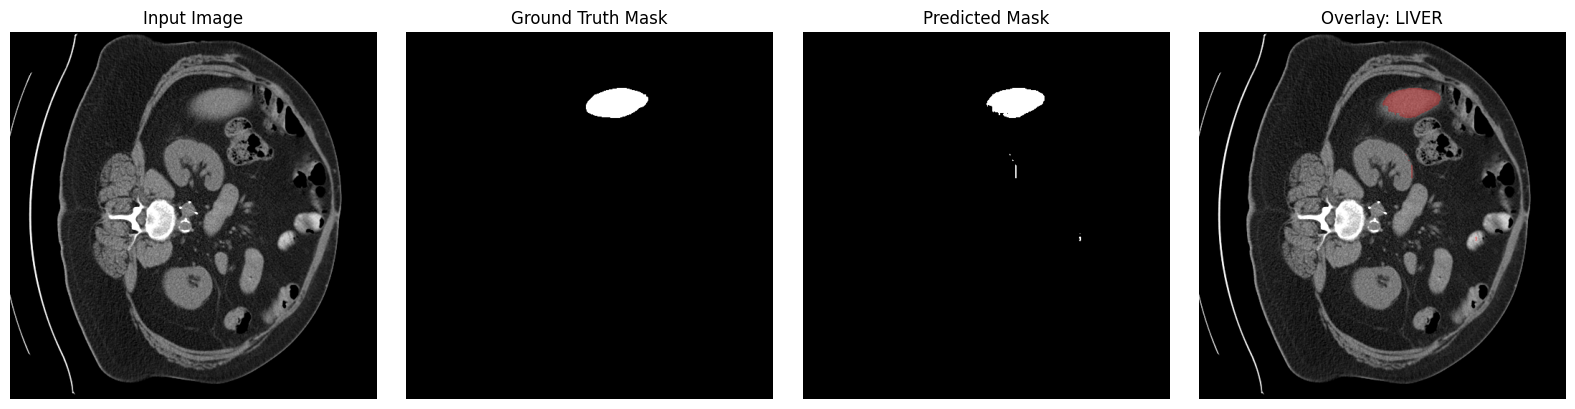

In [ ]:
import cv2
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Pull a sample from validation to visualize
sample = val_samples[1]
img_np = np.load(os.path.join(out_dir, sample['image_path']))   # Shape: (512, 512)
mask_np = np.load(os.path.join(out_dir, sample['mask_path'])) # Shape: (512, 512)

#  Replicate grayscale channel 3 times
image_tensor = torch.from_numpy(img_np).unsqueeze(0).unsqueeze(0).float().to(device)
image_tensor = image_tensor.repeat(1, 3, 1, 1)

# Upscale to 1024x1024 for MedSAM's vision backbone
image_tensor = F.interpolate(image_tensor, size=(1024, 1024), mode='bilinear', align_corners=False)

medsam_text_demo.eval()
with torch.no_grad():
    pred_logits = medsam_text_demo(image_tensor, prompt_lookup[sample['prompt']])

    # Upscale low-res 256x256 logits back to native 512x512 grid size before thresholding
    if pred_logits.shape[-2:] != mask_np.shape:
        pred_logits = F.interpolate(pred_logits, size=mask_np.shape, mode='bilinear', align_corners=False)

    pred_mask = (torch.sigmoid(pred_logits).squeeze().cpu().numpy() > 0.5).astype(np.uint8)


# Denormalize matrix back to standard 0-255 scale so the details don't turn completely black
img_8bit = (img_np * 255).astype(np.uint8)

# Convert grayscale structure to RGB color space to hold colored overlay pixels
img_rgb = cv2.cvtColor(img_8bit, cv2.COLOR_GRAY2RGB)

overlay = img_rgb.copy()
overlay[pred_mask == 1] = [255, 0, 0] # Color the predicted masks translucent Red
blend = cv2.addWeighted(img_rgb, 0.7, overlay, 0.3, 0)

# Render the clean 4-panel display layout
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(img_np, cmap='gray'); axes[0].set_title("Input Image"); axes[0].axis('off')
axes[1].imshow(mask_np, cmap='gray'); axes[1].set_title("Ground Truth Mask"); axes[1].axis('off')
axes[2].imshow(pred_mask, cmap='gray'); axes[2].set_title("Predicted Mask"); axes[2].axis('off')
axes[3].imshow(blend); axes[3].set_title(f"Overlay: {sample['prompt'].upper()}"); axes[3].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import os
import json
import numpy as np
import torch
import torch.nn.functional as F
from transformers import CLIPTokenizer

out_dir = '/content/drive/MyDrive/processed_medsam'
checkpoint_path = os.path.join(out_dir, "best_medsam_weights.pth")

def compute_hybrid_loss(pred_logits, targets, smooth=1e-5):
    bce_loss = F.binary_cross_entropy_with_logits(pred_logits, targets)
    probs = torch.sigmoid(pred_logits)
    intersection = (probs * targets).sum()
    union = probs.sum() + targets.sum()
    dice_loss = 1.0 - (2.0 * intersection + smooth) / (union + smooth)
    return bce_loss + dice_loss


tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-base-patch16")
prompt_lookup = {}
for organ in ["liver", "spleen", "pancreas"]:
    text_inputs = tokenizer(organ, padding="max_length", max_length=77, truncation=True, return_tensors="pt")
    prompt_lookup[organ] = text_inputs['input_ids'].to(device)

#Extract standard validation text matrices
with open(os.path.join(out_dir, 'test_manifest.json'), 'r') as f:
    test_samples = json.load(f)

if os.path.exists(checkpoint_path):
    medsam_text_demo.load_state_dict(torch.load(checkpoint_path, map_location=device))
    medsam_text_demo = medsam_text_demo.to(device)
    print("🎯 Optimal model weights restored onto device.")
else:
    print("⚠️ Warning: No checkpoint found. Falling back to baseline initialization.")


medsam_text_demo.eval()
test_loss = 0.0

with torch.no_grad():
    for sample in test_samples:
        img_np = np.load(os.path.join(out_dir, sample['image_path']))
        mask_np = np.load(os.path.join(out_dir, sample['mask_path']))

        # Convert 512x512 arrays to (1, 1, 512, 512)
        image_tensor = torch.from_numpy(img_np).unsqueeze(0).unsqueeze(0).float().to(device)
        mask_tensor = torch.from_numpy(mask_np).unsqueeze(0).unsqueeze(0).float().to(device)

        image_tensor = image_tensor.repeat(1, 3, 1, 1)
        image_tensor = F.interpolate(image_tensor, size=(1024, 1024), mode='bilinear', align_corners=False)

        pred_logits = medsam_text_demo(image_tensor, prompt_lookup[sample['prompt']])

        if pred_logits.shape[-2:] != mask_tensor.shape[-2:]:
            pred_logits = F.interpolate(pred_logits, size=mask_tensor.shape[-2:], mode='bilinear', align_corners=False)

        test_loss += compute_hybrid_loss(pred_logits, mask_tensor).item()

print(f"\n📊 Total Test Set Instances Evaluated: {len(test_samples)}")
print(f"✅ Test Dataset Average Loss: {test_loss / len(test_samples):.4f}")

🎯 Optimal model weights restored onto device.

📊 Total Test Set Instances Evaluated: 328
✅ Test Dataset Average Loss: 0.3234


The below cell is just used to collect the slices used during training.

In [ ]:
import os
import random

# Convert your train_scans list to a set for fast O(1) lookups
train_scans = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 21, 22, 23, 24]
train_scans_set = set(train_scans)
training_images = []

# Gather all image slices belonging strictly to training patients
for f in os.listdir(os.path.join(out_dir,"images")):
    if f.endswith('_img.npy'):
        parts = f.split('_') # e.g., ['spleen', 'scan01', 'slice020', 'img.npy']
        if len(parts) >= 2:
            scan_part = parts[1]
            scan_idx = int(''.join(filter(str.isdigit, scan_part)))
            if scan_idx in train_scans_set:
                training_images.append(f)

# Shuffle the list so picking an index behaves like a random selection
random.shuffle(training_images)

print(f"🎲 Successfully collected and randomized {len(training_images)} training slices!")

🎲 Successfully collected and randomized 1666 training slices!


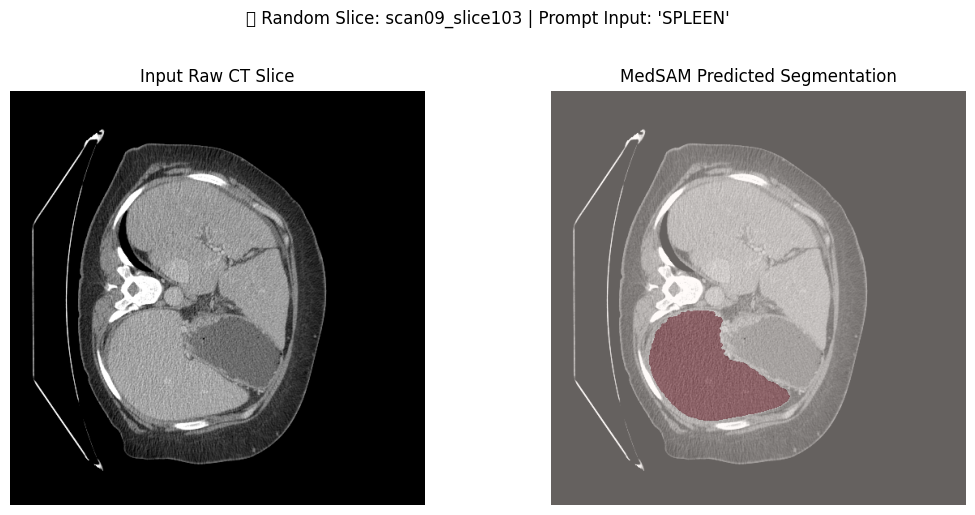

In [ ]:
#@title 🎛️ MedSAM Random Training Slice Tester { run: "auto" }
#@markdown Adjust the slider to jump to a random slice, or type a custom text prompt.

CHOOSE_IMAGE_INDEX = 57 #@param {type:"slider", min:0, max:200, step:1}
TEXT_PROMPT = "spleen" #@param {type:"string"}

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

img_name = training_images[CHOOSE_IMAGE_INDEX % len(training_images)]
img_np = np.load(os.path.join(os.path.join(out_dir,"images"), img_name))


text_inputs = tokenizer(TEXT_PROMPT, padding="max_length", max_length=77, truncation=True, return_tensors="pt")
tokens = text_inputs['input_ids'].to(device)

image_tensor = torch.from_numpy(img_np).unsqueeze(0).unsqueeze(0).float().to(device)
image_tensor = image_tensor.repeat(1, 3, 1, 1)
image_tensor = F.interpolate(image_tensor, size=(1024, 1024), mode='bilinear', align_corners=False)


medsam_text_demo.eval()
with torch.no_grad():
    pred_logits = medsam_text_demo(image_tensor, tokens)

    # Rescale back to match original image dimensions
    if pred_logits.shape[-2:] != img_np.shape:
        pred_logits = F.interpolate(pred_logits, size=img_np.shape, mode='bilinear', align_corners=False)

    pred_mask = (torch.sigmoid(pred_logits).squeeze().cpu().numpy() > 0.5).astype(np.uint8)


fig, axes = plt.subplots(1, 2, figsize=(11, 5))
parts = img_name.split('_')
slice_id = f"{parts[1]}_{parts[2]}" # e.g., scan05_slice022

fig.suptitle(f"📍 Random Slice: {slice_id} | Prompt Input: '{TEXT_PROMPT.upper()}'", fontsize=12, y=1.02)

axes[0].imshow(img_np, cmap='gray')
axes[0].set_title("Input Raw CT Slice")
axes[0].axis('off')

axes[1].imshow(img_np, cmap='gray')
axes[1].imshow(pred_mask, cmap='Reds', alpha=0.4)
axes[1].set_title("MedSAM Predicted Segmentation")
axes[1].axis('off')

plt.tight_layout()
plt.show()